# Alberta Postsecondary Enrolment — Student Status Analysis

## Objective

This analysis examines how the composition of Alberta postsecondary enrolment changed between 2014/2015 and 2023/2024, with a particular focus on Canadian and international students.

Key questions:

1. How have Canadian and international enrolments changed over time?
2. How has the international share of Alberta enrolment changed?
3. Which student group contributed most to Alberta's enrolment growth?
4. Which institutions experienced the largest growth in international enrolment?
5. Which institutions have the highest international student share?
6. How does the University of Alberta compare with the provincial trend?

Source: Statistics Canada Table 37-10-0277-01.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

In [2]:
file_path = "../data/processed/alberta_student_status_clean.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (780, 10)


,Institution_Raw,Institution,Institution_Standardized,Academic_Year,Enrolment,Student_Status,Province,Record_Type,Academic_Year_Start,Academic_Year_End
0,Alberta 11,Alberta,Alberta,2014/2015,"184,026.00",Total,Alberta,Province Total,2014,2015
1,"University of Alberta, Alberta",University of Alberta,University of Alberta,2014/2015,"38,520.00",Total,Alberta,Institution,2014,2015
2,"Athabasca University, Alberta",Athabasca University,Athabasca University,2014/2015,"17,577.00",Total,Alberta,Institution,2014,2015
3,"University of Calgary, Alberta",University of Calgary,University of Calgary,2014/2015,"31,308.00",Total,Alberta,Institution,2014,2015
4,"Burman University, Alberta",Burman University,Burman University,2014/2015,474.00,Total,Alberta,Institution,2014,2015


## Dataset Verification

Confirm the structure, student-status categories, academic-year coverage, and institution coverage before beginning the analysis.

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nStudent status categories:")
print(df["Student_Status"].value_counts())

print("\nAcademic years:")
print(sorted(df["Academic_Year"].unique()))

print("\nNumber of entities:")
print(df["Institution_Standardized"].nunique())

Shape: (780, 10)

Columns:
['Institution_Raw', 'Institution', 'Institution_Standardized', 'Academic_Year', 'Enrolment', 'Student_Status', 'Province', 'Record_Type', 'Academic_Year_Start', 'Academic_Year_End']

Student status categories:
Student_Status
Total            260
Canadian         260
International    260
Name: count, dtype: int64

Academic years:
['2014/2015', '2015/2016', '2016/2017', '2017/2018', '2018/2019', '2019/2020', '2020/2021', '2021/2022', '2022/2023', '2023/2024']

Number of entities:
26


## Analysis 1 — Alberta Student Composition Over Time

Use the reported Alberta provincial aggregate to examine how Canadian and international enrolment changed over the ten-year period.

In [4]:
alberta = (
    df[df["Institution_Standardized"] == "Alberta"]
    [
        [
            "Academic_Year",
            "Academic_Year_Start",
            "Student_Status",
            "Enrolment"
        ]
    ]
    .copy()
)

alberta = alberta.sort_values(
    ["Academic_Year_Start", "Student_Status"]
)

print("Alberta records:", len(alberta))

alberta.head(10)

Alberta records: 30


,Academic_Year,Academic_Year_Start,Student_Status,Enrolment
260,2014/2015,2014,Canadian,"167,463.00"
520,2014/2015,2014,International,"16,458.00"
0,2014/2015,2014,Total,"184,026.00"
286,2015/2016,2015,Canadian,"167,946.00"
546,2015/2016,2015,International,"17,478.00"
26,2015/2016,2015,Total,"185,679.00"
312,2016/2017,2016,Canadian,"172,506.00"
572,2016/2017,2016,International,"18,303.00"
52,2016/2017,2016,Total,"190,947.00"
338,2017/2018,2017,Canadian,"175,065.00"


In [5]:
alberta_status = (
    alberta
    .pivot(
        index=["Academic_Year", "Academic_Year_Start"],
        columns="Student_Status",
        values="Enrolment"
    )
    .reset_index()
    .sort_values("Academic_Year_Start")
)

alberta_status

Student_Status,Academic_Year,Academic_Year_Start,Canadian,International,Total
0,2014/2015,2014,"167,463.00","16,458.00","184,026.00"
1,2015/2016,2015,"167,946.00","17,478.00","185,679.00"
2,2016/2017,2016,"172,506.00","18,303.00","190,947.00"
3,2017/2018,2017,"175,065.00","18,798.00","194,010.00"
4,2018/2019,2018,"178,617.00","21,663.00","200,391.00"
5,2019/2020,2019,"179,178.00","24,636.00","203,823.00"
6,2020/2021,2020,"179,850.00","23,667.00","203,523.00"
7,2021/2022,2021,"178,239.00","25,311.00","203,580.00"
8,2022/2023,2022,"175,698.00","30,018.00","205,734.00"
9,2023/2024,2023,"179,535.00","37,416.00","216,957.00"


In [6]:
alberta_status["International_Share_Pct"] = (
    alberta_status["International"]
    / alberta_status["Total"]
    * 100
)

alberta_status["Canadian_Share_Pct"] = (
    alberta_status["Canadian"]
    / alberta_status["Total"]
    * 100
)

alberta_status[
    [
        "Academic_Year",
        "Total",
        "Canadian",
        "International",
        "Canadian_Share_Pct",
        "International_Share_Pct"
    ]
].round(2)

Student_Status,Academic_Year,Total,Canadian,International,Canadian_Share_Pct,International_Share_Pct
0,2014/2015,"184,026.00","167,463.00","16,458.00",91.00,8.94
1,2015/2016,"185,679.00","167,946.00","17,478.00",90.45,9.41
2,2016/2017,"190,947.00","172,506.00","18,303.00",90.34,9.59
3,2017/2018,"194,010.00","175,065.00","18,798.00",90.24,9.69
4,2018/2019,"200,391.00","178,617.00","21,663.00",89.13,10.81
5,2019/2020,"203,823.00","179,178.00","24,636.00",87.91,12.09
6,2020/2021,"203,523.00","179,850.00","23,667.00",88.37,11.63
7,2021/2022,"203,580.00","178,239.00","25,311.00",87.55,12.43
8,2022/2023,"205,734.00","175,698.00","30,018.00",85.40,14.59
9,2023/2024,"216,957.00","179,535.00","37,416.00",82.75,17.25


## Analysis 2 — Canadian vs. International Enrolment Growth

Compare the absolute and percentage change in Canadian and international
student enrolment between 2014/15 and 2023/24.

In [7]:
start = alberta_status.iloc[0]
end = alberta_status.iloc[-1]

growth_summary = pd.DataFrame({
    "Student_Status": [
        "Total",
        "Canadian",
        "International"
    ],
    "2014_15": [
        start["Total"],
        start["Canadian"],
        start["International"]
    ],
    "2023_24": [
        end["Total"],
        end["Canadian"],
        end["International"]
    ]
})

growth_summary["Absolute_Change"] = (
    growth_summary["2023_24"]
    - growth_summary["2014_15"]
)

growth_summary["Growth_Pct"] = (
    growth_summary["Absolute_Change"]
    / growth_summary["2014_15"]
    * 100
)

growth_summary.round(2)

,Student_Status,2014_15,2023_24,Absolute_Change,Growth_Pct
0,Total,"184,026.00","216,957.00","32,931.00",17.89
1,Canadian,"167,463.00","179,535.00","12,072.00",7.21
2,International,"16,458.00","37,416.00","20,958.00",127.34


In [8]:
total_net_growth = (
    end["Total"]
    - start["Total"]
)

canadian_net_growth = (
    end["Canadian"]
    - start["Canadian"]
)

international_net_growth = (
    end["International"]
    - start["International"]
)

canadian_contribution = (
    canadian_net_growth
    / total_net_growth
    * 100
)

international_contribution = (
    international_net_growth
    / total_net_growth
    * 100
)

print(f"Total net enrolment increase: {total_net_growth:,.0f}")
print(f"Canadian enrolment increase: {canadian_net_growth:,.0f}")
print(f"International enrolment increase: {international_net_growth:,.0f}")

print(
    f"\nCanadian increase equivalent to: "
    f"{canadian_contribution:.2f}% of total net growth"
)

print(
    f"International increase equivalent to: "
    f"{international_contribution:.2f}% of total net growth"
)

Total net enrolment increase: 32,931
Canadian enrolment increase: 12,072
International enrolment increase: 20,958

Canadian increase equivalent to: 36.66% of total net growth
International increase equivalent to: 63.64% of total net growth


In [9]:
#The increase in international enrolment was equivalent to nearly two-thirds of Alberta's net reported 
#postsecondary enrolment growth between 2014/15 and 2023/24.

In [10]:
international_share_start = start["International_Share_Pct"]
international_share_end = end["International_Share_Pct"]

share_change_pp = (
    international_share_end
    - international_share_start
)

print(
    f"International share in 2014/15: "
    f"{international_share_start:.2f}%"
)

print(
    f"International share in 2023/24: "
    f"{international_share_end:.2f}%"
)

print(
    f"Change: {share_change_pp:.2f} percentage points"
)

International share in 2014/15: 8.94%
International share in 2023/24: 17.25%
Change: 8.30 percentage points


In [11]:
alberta_status["Canadian_YoY_Pct"] = (
    alberta_status["Canadian"]
    .pct_change()
    * 100
)

alberta_status["International_YoY_Pct"] = (
    alberta_status["International"]
    .pct_change()
    * 100
)

alberta_status[
    [
        "Academic_Year",
        "Canadian",
        "Canadian_YoY_Pct",
        "International",
        "International_YoY_Pct"
    ]
].round(2)

Student_Status,Academic_Year,Canadian,Canadian_YoY_Pct,International,International_YoY_Pct
0,2014/2015,"167,463.00",NaN,"16,458.00",NaN
1,2015/2016,"167,946.00",0.29,"17,478.00",6.20
2,2016/2017,"172,506.00",2.72,"18,303.00",4.72
3,2017/2018,"175,065.00",1.48,"18,798.00",2.70
4,2018/2019,"178,617.00",2.03,"21,663.00",15.24
5,2019/2020,"179,178.00",0.31,"24,636.00",13.72
6,2020/2021,"179,850.00",0.38,"23,667.00",-3.93
7,2021/2022,"178,239.00",-0.90,"25,311.00",6.95
8,2022/2023,"175,698.00",-1.43,"30,018.00",18.60
9,2023/2024,"179,535.00",2.18,"37,416.00",24.65


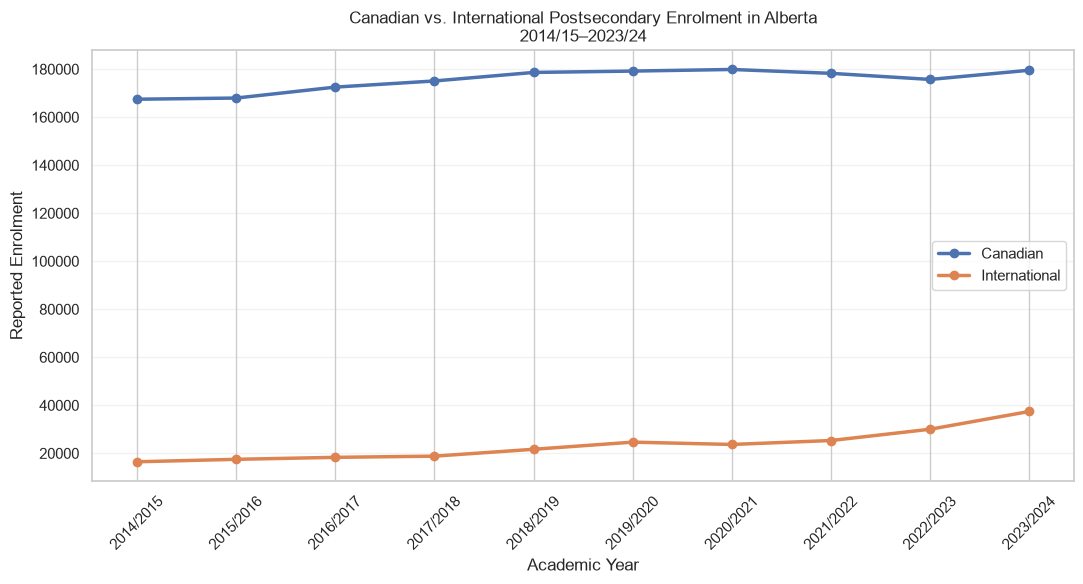

In [12]:
plt.figure(figsize=(11, 6))

plt.plot(
    alberta_status["Academic_Year"],
    alberta_status["Canadian"],
    marker="o",
    linewidth=2.5,
    label="Canadian"
)

plt.plot(
    alberta_status["Academic_Year"],
    alberta_status["International"],
    marker="o",
    linewidth=2.5,
    label="International"
)

plt.title(
    "Canadian vs. International Postsecondary Enrolment in Alberta\n"
    "2014/15–2023/24"
)

plt.xlabel("Academic Year")
plt.ylabel("Reported Enrolment")

plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

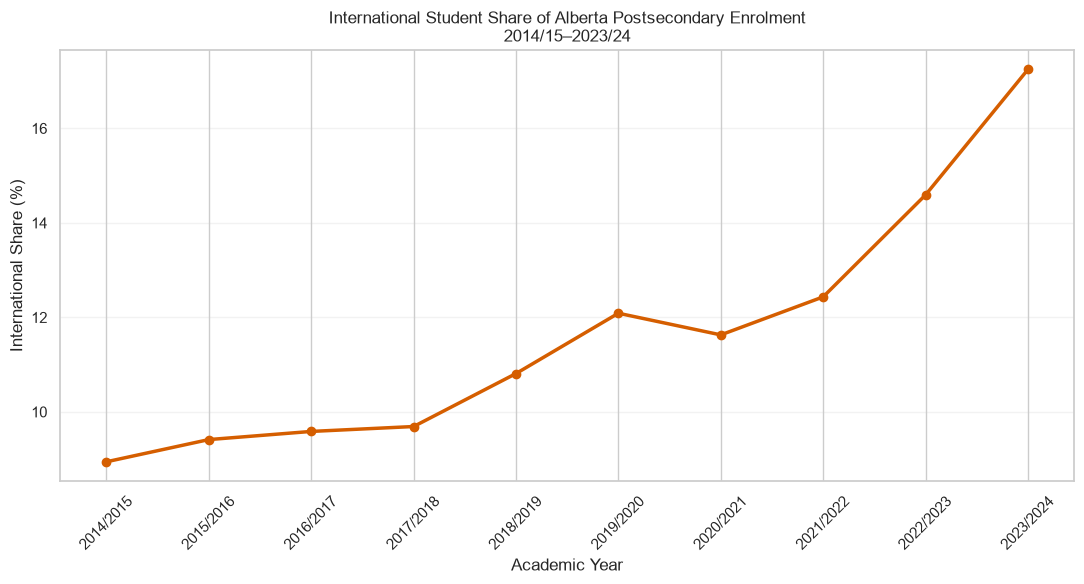

In [13]:
plt.figure(figsize=(11, 6))

plt.plot(
    alberta_status["Academic_Year"],
    alberta_status["International_Share_Pct"],
    marker="o",
    linewidth=2.5,
    color="#D55E00"
)

plt.title(
    "International Student Share of Alberta Postsecondary Enrolment\n"
    "2014/15–2023/24"
)

plt.xlabel("Academic Year")
plt.ylabel("International Share (%)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Analysis 3 — International Enrolment Growth by Institution

This analysis examines how international enrolment changed across Alberta
postsecondary institutions between 2014/15 and 2023/24.

The objective is to identify which institutions contributed most to the
province-wide increase in international enrolment.

In [14]:
international = (
    df_long[
        (df_long["Student_Status"] == "International") &
        (df_long["Institution_Standardized"] != "Alberta")
    ]
    .copy()
)

international.shape

NameError: name 'df_long' is not defined

In [15]:
%whos DataFrame

Variable         Type         Data/Info
---------------------------------------
alberta          DataFrame    Shape: (30, 4)
alberta_status   DataFrame    Shape: (10, 9)
df               DataFrame    Shape: (780, 10)
growth_summary   DataFrame    Shape: (3, 5)


In [16]:
%whos DataFrame

Variable         Type         Data/Info
---------------------------------------
alberta          DataFrame    Shape: (30, 4)
alberta_status   DataFrame    Shape: (10, 9)
df               DataFrame    Shape: (780, 10)
growth_summary   DataFrame    Shape: (3, 5)


In [17]:
international = (
    df[
        (df["Student_Status"] == "International") &
        (df["Institution_Standardized"] != "Alberta")
    ]
    .copy()
)

international.shape

(250, 10)

In [18]:
print(
    "Institutions:",
    international["Institution_Standardized"].nunique()
)

print(
    "Academic years:",
    international["Academic_Year"].nunique()
)

print(
    "Rows:",
    len(international)
)

Institutions: 25
Academic years: 10
Rows: 250


In [19]:
international[
    "Institution_Standardized"
].sort_values().unique()

<ArrowStringArray>
[          'Alberta University of the Arts',
                       'Ambrose University',
                     'Athabasca University',
                       'Bow Valley College',
                        'Burman University',
         'Concordia University of Edmonton',
                 'Grant MacEwan University',
                           'Keyano College',
                         'Lakeland College',
                       'Lethbridge College',
                     'Medicine Hat College',
                   'Mount Royal University',
                         'NorQuest College',
 'Northern Alberta Institute of Technology',
                   'Northern Lakes College',
                 'Northwestern Polytechnic',
                             'Olds College',
                          'Portage College',
                     'Red Deer Polytechnic',
 'Southern Alberta Institute of Technology',
                    'St. Mary's University',
                    'The King's Univ

In [20]:
intl_start = (
    international[
        international["Academic_Year"] == "2014/2015"
    ][
        ["Institution_Standardized", "Enrolment"]
    ]
    .rename(
        columns={"Enrolment": "International_2014_15"}
    )
)

intl_end = (
    international[
        international["Academic_Year"] == "2023/2024"
    ][
        ["Institution_Standardized", "Enrolment"]
    ]
    .rename(
        columns={"Enrolment": "International_2023_24"}
    )
)

intl_growth = intl_start.merge(
    intl_end,
    on="Institution_Standardized",
    how="inner"
)

In [21]:
intl_growth["Absolute_Change"] = (
    intl_growth["International_2023_24"]
    - intl_growth["International_2014_15"]
)

intl_growth["Growth_Pct"] = (
    intl_growth["Absolute_Change"]
    / intl_growth["International_2014_15"]
    * 100
)

In [22]:
intl_growth = (
    intl_growth
    .sort_values(
        "Absolute_Change",
        ascending=False
    )
    .reset_index(drop=True)
)

In [23]:
intl_growth[
    [
        "Institution_Standardized",
        "International_2014_15",
        "International_2023_24",
        "Absolute_Change",
        "Growth_Pct"
    ]
].round(2)

,Institution_Standardized,International_2014_15,International_2023_24,Absolute_Change,Growth_Pct
0,University of Calgary,"3,111.00","7,113.00","4,002.00",128.64
1,Southern Alberta Institute of Technology,"1,380.00","5,169.00","3,789.00",274.57
2,NorQuest College,99.00,"3,645.00","3,546.00","3,581.82"
3,Bow Valley College,465.00,"2,679.00","2,214.00",476.13
4,University of Alberta,"6,831.00","8,331.00","1,500.00",21.96
5,Northern Alberta Institute of Technology,"1,215.00","2,460.00","1,245.00",102.47
6,Lethbridge College,204.00,"1,131.00",927.00,454.41
7,University of Lethbridge,543.00,"1,332.00",789.00,145.30
8,Red Deer Polytechnic,66.00,780.00,714.00,"1,081.82"
9,Keyano College,72.00,756.00,684.00,950.00


In [24]:
alberta_intl_growth = (
    end["International"]
    - start["International"]
)

In [25]:
intl_growth["Contribution_to_Provincial_Growth_Pct"] = (
    intl_growth["Absolute_Change"]
    / alberta_intl_growth
    * 100
)

In [26]:
intl_growth[
    [
        "Institution_Standardized",
        "International_2014_15",
        "International_2023_24",
        "Absolute_Change",
        "Growth_Pct",
        "Contribution_to_Provincial_Growth_Pct"
    ]
].head(10).round(2)

,Institution_Standardized,International_2014_15,International_2023_24,Absolute_Change,Growth_Pct,Contribution_to_Provincial_Growth_Pct
0,University of Calgary,"3,111.00","7,113.00","4,002.00",128.64,19.10
1,Southern Alberta Institute of Technology,"1,380.00","5,169.00","3,789.00",274.57,18.08
2,NorQuest College,99.00,"3,645.00","3,546.00","3,581.82",16.92
3,Bow Valley College,465.00,"2,679.00","2,214.00",476.13,10.56
4,University of Alberta,"6,831.00","8,331.00","1,500.00",21.96,7.16
5,Northern Alberta Institute of Technology,"1,215.00","2,460.00","1,245.00",102.47,5.94
6,Lethbridge College,204.00,"1,131.00",927.00,454.41,4.42
7,University of Lethbridge,543.00,"1,332.00",789.00,145.30,3.76
8,Red Deer Polytechnic,66.00,780.00,714.00,"1,081.82",3.41
9,Keyano College,72.00,756.00,684.00,950.00,3.26


In [27]:
top3_intl_growth = (
    intl_growth
    .head(3)["Absolute_Change"]
    .sum()
)

top5_intl_growth = (
    intl_growth
    .head(5)["Absolute_Change"]
    .sum()
)

top3_share = (
    top3_intl_growth
    / alberta_intl_growth
    * 100
)

top5_share = (
    top5_intl_growth
    / alberta_intl_growth
    * 100
)

print(
    f"Top 3 institutions added: "
    f"{top3_intl_growth:,.0f} international enrolments"
)

print(
    f"Equivalent to {top3_share:.2f}% "
    f"of Alberta's international enrolment increase"
)

print(
    f"\nTop 5 institutions added: "
    f"{top5_intl_growth:,.0f} international enrolments"
)

print(
    f"Equivalent to {top5_share:.2f}% "
    f"of Alberta's international enrolment increase"
)

Top 3 institutions added: 11,337 international enrolments
Equivalent to 54.09% of Alberta's international enrolment increase

Top 5 institutions added: 15,051 international enrolments
Equivalent to 71.82% of Alberta's international enrolment increase


### Key Finding

International enrolment growth was concentrated among a relatively small number
of Alberta institutions. The top three institutions accounted for approximately
54.1% of the province-wide increase in international enrolment, while the top
five accounted for approximately 71.8%.

The University of Calgary recorded the largest absolute increase (+4,002),
followed by the Southern Alberta Institute of Technology (+3,789) and NorQuest
College (+3,546). This suggests that Alberta's international enrolment expansion
was driven disproportionately by a subset of institutions rather than being
distributed evenly across the postsecondary system.

In [28]:
status_2023 = df[
    (df["Academic_Year"] == "2023/2024") &
    (df["Institution_Standardized"] != "Alberta")
].copy()

status_2023.shape

(75, 10)

In [29]:
exposure_2023 = (
    status_2023
    .pivot(
        index="Institution_Standardized",
        columns="Student_Status",
        values="Enrolment"
    )
    .reset_index()
)

exposure_2023.head()

Student_Status,Institution_Standardized,Canadian,International,Total
0,Alberta University of the Arts,"1,101.00",99.00,"1,200.00"
1,Ambrose University,510.00,39.00,552.00
2,Athabasca University,"15,486.00",516.00,"16,005.00"
3,Bow Valley College,"6,252.00","2,679.00","8,931.00"
4,Burman University,261.00,72.00,333.00


In [30]:
exposure_2023["International_Share_Pct"] = (
    exposure_2023["International"]
    / exposure_2023["Total"]
    * 100
)

In [31]:
exposure_2023 = (
    exposure_2023
    .sort_values(
        "International_Share_Pct",
        ascending=False
    )
    .reset_index(drop=True)
)

exposure_2023[
    [
        "Institution_Standardized",
        "Total",
        "Canadian",
        "International",
        "International_Share_Pct"
    ]
].round(2)

Student_Status,Institution_Standardized,Total,Canadian,International,International_Share_Pct
0,Keyano College,"1,809.00","1,053.00",756.00,41.79
1,NorQuest College,"10,299.00","6,654.00","3,645.00",35.39
2,Southern Alberta Institute of Technology,"15,306.00","10,134.00","5,169.00",33.77
3,Bow Valley College,"8,931.00","6,252.00","2,679.00",30.00
4,Lethbridge College,"5,103.00","3,972.00","1,131.00",22.16
5,Burman University,333.00,261.00,72.00,21.62
6,Concordia University of Edmonton,"2,568.00","2,076.00",495.00,19.28
7,Olds College,"2,223.00","1,797.00",426.00,19.16
8,Northern Alberta Institute of Technology,"12,993.00","10,533.00","2,460.00",18.93
9,University of Alberta,"45,306.00","36,972.00","8,331.00",18.39


In [32]:
print(
    "Highest international share:",
    f"{exposure_2023['International_Share_Pct'].max():.2f}%"
)

print(
    "Lowest international share:",
    f"{exposure_2023['International_Share_Pct'].min():.2f}%"
)

print(
    "Institutions above 20%:",
    (exposure_2023["International_Share_Pct"] >= 20).sum()
)

print(
    "Institutions above 30%:",
    (exposure_2023["International_Share_Pct"] >= 30).sum()
)

Highest international share: 41.79%
Lowest international share: 0.65%
Institutions above 20%: 6
Institutions above 30%: 3


### Key Finding — International Enrolment Exposure

International enrolment represented a substantial share of total enrolment at
several Alberta institutions in 2023/24. Keyano College had the highest
international share at approximately 41.8%, followed by NorQuest College
(35.4%) and the Southern Alberta Institute of Technology (33.8%).

Six institutions had international students representing more than 20% of
reported total enrolment. This indicates that international enrolment exposure
varied considerably across Alberta's postsecondary institutions.

In [33]:
growth_exposure = intl_growth.merge(
    exposure_2023[
        [
            "Institution_Standardized",
            "Total",
            "International",
            "International_Share_Pct"
        ]
    ],
    on="Institution_Standardized",
    how="inner"
)

growth_exposure.shape

(25, 9)

In [34]:
growth_exposure = growth_exposure[
    [
        "Institution_Standardized",
        "International_2014_15",
        "International_2023_24",
        "Absolute_Change",
        "Growth_Pct",
        "Contribution_to_Provincial_Growth_Pct",
        "Total",
        "International_Share_Pct"
    ]
]

growth_exposure.head()

,Institution_Standardized,International_2014_15,International_2023_24,Absolute_Change,Growth_Pct,Contribution_to_Provincial_Growth_Pct,Total,International_Share_Pct
0,University of Calgary,"3,111.00","7,113.00","4,002.00",128.64,19.10,"38,715.00",18.37
1,Southern Alberta Institute of Technology,"1,380.00","5,169.00","3,789.00",274.57,18.08,"15,306.00",33.77
2,NorQuest College,99.00,"3,645.00","3,546.00","3,581.82",16.92,"10,299.00",35.39
3,Bow Valley College,465.00,"2,679.00","2,214.00",476.13,10.56,"8,931.00",30.00
4,University of Alberta,"6,831.00","8,331.00","1,500.00",21.96,7.16,"45,306.00",18.39


In [35]:
median_growth = growth_exposure["Absolute_Change"].median()
median_exposure = growth_exposure["International_Share_Pct"].median()

print(f"Median international enrolment growth: {median_growth:,.0f}")
print(f"Median international enrolment share: {median_exposure:.2f}%")

Median international enrolment growth: 261
Median international enrolment share: 15.74%


In [36]:
def classify_institution(row):
    
    high_growth = row["Absolute_Change"] >= median_growth
    high_exposure = row["International_Share_Pct"] >= median_exposure
    
    if high_growth and high_exposure:
        return "High Growth / High Exposure"
    
    elif high_growth and not high_exposure:
        return "High Growth / Lower Exposure"
    
    elif not high_growth and high_exposure:
        return "Lower Growth / High Exposure"
    
    else:
        return "Lower Growth / Lower Exposure"


growth_exposure["Growth_Exposure_Group"] = (
    growth_exposure.apply(
        classify_institution,
        axis=1
    )
)

In [37]:
growth_exposure[
    [
        "Institution_Standardized",
        "Absolute_Change",
        "International_Share_Pct",
        "Growth_Exposure_Group"
    ]
].sort_values(
    "Absolute_Change",
    ascending=False
).round(2)

,Institution_Standardized,Absolute_Change,International_Share_Pct,Growth_Exposure_Group
0,University of Calgary,"4,002.00",18.37,High Growth / High Exposure
1,Southern Alberta Institute of Technology,"3,789.00",33.77,High Growth / High Exposure
2,NorQuest College,"3,546.00",35.39,High Growth / High Exposure
3,Bow Valley College,"2,214.00",30.00,High Growth / High Exposure
4,University of Alberta,"1,500.00",18.39,High Growth / High Exposure
5,Northern Alberta Institute of Technology,"1,245.00",18.93,High Growth / High Exposure
6,Lethbridge College,927.00,22.16,High Growth / High Exposure
7,University of Lethbridge,789.00,15.34,High Growth / Lower Exposure
8,Red Deer Polytechnic,714.00,18.39,High Growth / High Exposure
9,Keyano College,684.00,41.79,High Growth / High Exposure


In [38]:
growth_exposure[
    "Growth_Exposure_Group"
].value_counts()

Growth_Exposure_Group
High Growth / High Exposure      11
Lower Growth / Lower Exposure    10
High Growth / Lower Exposure      2
Lower Growth / High Exposure      2
Name: count, dtype: int64

In [39]:
growth_exposure[
    growth_exposure["Growth_Exposure_Group"]
    == "High Growth / High Exposure"
][
    [
        "Institution_Standardized",
        "Absolute_Change",
        "International_Share_Pct",
        "Contribution_to_Provincial_Growth_Pct"
    ]
].sort_values(
    "Absolute_Change",
    ascending=False
).round(2)

,Institution_Standardized,Absolute_Change,International_Share_Pct,Contribution_to_Provincial_Growth_Pct
0,University of Calgary,"4,002.00",18.37,19.10
1,Southern Alberta Institute of Technology,"3,789.00",33.77,18.08
2,NorQuest College,"3,546.00",35.39,16.92
3,Bow Valley College,"2,214.00",30.00,10.56
4,University of Alberta,"1,500.00",18.39,7.16
5,Northern Alberta Institute of Technology,"1,245.00",18.93,5.94
6,Lethbridge College,927.00,22.16,4.42
8,Red Deer Polytechnic,714.00,18.39,3.41
9,Keyano College,684.00,41.79,3.26
10,Olds College,384.00,19.16,1.83


### Key Finding — Growth and International Enrolment Exposure

International enrolment growth was concentrated among institutions that also
had relatively high international student representation in 2023/24.

Using the median international enrolment increase (261 students) and median
international enrolment share (15.74%) as comparative thresholds, 11 of the
25 institutions were classified as High Growth / High Exposure.

The University of Calgary recorded the largest absolute increase in
international enrolment (+4,002), while institutions such as SAIT,
NorQuest College, and Bow Valley College combined substantial enrolment
growth with international student shares of approximately 30% or more.

Keyano College presents a different pattern: its absolute increase was smaller
(+684), but international students represented 41.79% of its reported
enrolment in 2023/24, the highest share among the institutions analyzed.

These results demonstrate that institutional exposure to international
enrolment varies not only by the number of international students added,
but also by their share of the institution's overall enrolment.

In [40]:
canadian = (
    df[df["Student_Status"] == "Canadian"]
    .pivot(
        index="Institution_Standardized",
        columns="Academic_Year",
        values="Enrolment"
    )
)

international = (
    df[df["Student_Status"] == "International"]
    .pivot(
        index="Institution_Standardized",
        columns="Academic_Year",
        values="Enrolment"
    )
)




In [41]:
growth_comparison = pd.DataFrame({
    "Canadian_2014_15": canadian["2014/2015"],
    "Canadian_2023_24": canadian["2023/2024"],
    "International_2014_15": international["2014/2015"],
    "International_2023_24": international["2023/2024"]
}).reset_index()

growth_comparison["Canadian_Change"] = (
    growth_comparison["Canadian_2023_24"]
    - growth_comparison["Canadian_2014_15"]
)

growth_comparison["International_Change"] = (
    growth_comparison["International_2023_24"]
    - growth_comparison["International_2014_15"]
)

growth_comparison["Combined_Change"] = (
    growth_comparison["Canadian_Change"]
    + growth_comparison["International_Change"]
)

In [42]:
growth_comparison[
    [
        "Institution_Standardized",
        "Canadian_Change",
        "International_Change",
        "Combined_Change"
    ]
].sort_values(
    "International_Change",
    ascending=False
).round(0)

,Institution_Standardized,Canadian_Change,International_Change,Combined_Change
0,Alberta,"12,072.00","20,958.00","33,030.00"
24,University of Calgary,"3,402.00","4,002.00","7,404.00"
20,Southern Alberta Institute of Technology,"-2,781.00","3,789.00","1,008.00"
13,NorQuest College,"2,541.00","3,546.00","6,087.00"
4,Bow Valley College,-177.00,"2,214.00","2,037.00"
23,University of Alberta,"5,283.00","1,500.00","6,783.00"
14,Northern Alberta Institute of Technology,930.00,"1,245.00","2,175.00"
10,Lethbridge College,-237.00,927.00,690.00
25,University of Lethbridge,-264.00,789.00,525.00
19,Red Deer Polytechnic,186.00,714.00,900.00


In [43]:
international_offset = growth_comparison[
    (growth_comparison["Canadian_Change"] < 0) &
    (growth_comparison["International_Change"] > 0)
].copy()

international_offset[
    [
        "Institution_Standardized",
        "Canadian_Change",
        "International_Change",
        "Combined_Change"
    ]
].sort_values(
    "International_Change",
    ascending=False
)

,Institution_Standardized,Canadian_Change,International_Change,Combined_Change
20,Southern Alberta Institute of Technology,"-2,781.00","3,789.00","1,008.00"
4,Bow Valley College,-177.00,"2,214.00","2,037.00"
10,Lethbridge College,-237.00,927.00,690.00
25,University of Lethbridge,-264.00,789.00,525.00
8,Keyano College,-306.00,684.00,378.00
16,Northwestern Polytechnic,-354.00,261.00,-93.00
3,Athabasca University,"-1,725.00",162.00,"-1,563.00"
11,Medicine Hat College,-126.00,123.00,-3.00
5,Burman University,-162.00,21.00,-141.00


### Key Finding — International Enrolment Offset Declines in Canadian Enrolment

Nine Alberta institutions experienced a decline in Canadian enrolment between
2014/15 and 2023/24 while simultaneously recording growth in international
enrolment.

At five institutions—Southern Alberta Institute of Technology (SAIT),
Bow Valley College, Lethbridge College, University of Lethbridge, and
Keyano College—the increase in international enrolment was large enough to
more than offset the decline in Canadian enrolment, resulting in positive
combined enrolment growth.

SAIT provides the strongest example: Canadian enrolment decreased by 2,781
students, while international enrolment increased by 3,789, producing a net
combined increase of approximately 1,008 students.

Bow Valley College experienced a relatively small decline of 177 Canadian
students but gained 2,214 international students, resulting in approximately
2,037 additional students overall.

At Northwestern Polytechnic, Athabasca University, Medicine Hat College, and
Burman University, international enrolment growth was not sufficient to fully
offset the decline in Canadian enrolment.

These results show that international enrolment played substantially different
roles across Alberta institutions, ranging from supplementing growth to
offsetting declines in Canadian enrolment.

In [44]:
offset_analysis = international_offset.copy()

offset_analysis["Offset_Ratio_Pct"] = (
    offset_analysis["International_Change"]
    / abs(offset_analysis["Canadian_Change"])
    * 100
)

offset_analysis[
    [
        "Institution_Standardized",
        "Canadian_Change",
        "International_Change",
        "Combined_Change",
        "Offset_Ratio_Pct"
    ]
].sort_values(
    "Offset_Ratio_Pct",
    ascending=False
).round(2)

,Institution_Standardized,Canadian_Change,International_Change,Combined_Change,Offset_Ratio_Pct
4,Bow Valley College,-177.00,"2,214.00","2,037.00","1,250.85"
10,Lethbridge College,-237.00,927.00,690.00,391.14
25,University of Lethbridge,-264.00,789.00,525.00,298.86
8,Keyano College,-306.00,684.00,378.00,223.53
20,Southern Alberta Institute of Technology,"-2,781.00","3,789.00","1,008.00",136.25
11,Medicine Hat College,-126.00,123.00,-3.00,97.62
16,Northwestern Polytechnic,-354.00,261.00,-93.00,73.73
5,Burman University,-162.00,21.00,-141.00,12.96
3,Athabasca University,"-1,725.00",162.00,"-1,563.00",9.39


In [45]:
offset_analysis["Offset_Category"] = np.where(
    offset_analysis["Offset_Ratio_Pct"] >= 100,
    "Fully Offset",
    "Partially Offset"
)

offset_analysis["Offset_Category"].value_counts()

Offset_Category
Fully Offset        5
Partially Offset    4
Name: count, dtype: int64

### International Enrolment as an Offset to Canadian Enrolment Decline

Among the nine institutions where Canadian enrolment declined while
international enrolment increased, international growth fully offset the
Canadian decline at five institutions and partially offset it at four.

Bow Valley College showed the strongest offset: its increase of 2,214
international students was more than 12 times the size of its decline of
177 Canadian students. Lethbridge College and the University of Lethbridge
also recorded international increases approximately 3.9 and 3.0 times their
respective Canadian enrolment declines.

SAIT presents a particularly important case because of the scale involved.
Despite a decline of 2,781 Canadian students, an increase of 3,789
international students resulted in positive combined growth of approximately
1,008 students.

Medicine Hat College came close to a complete offset, with international
growth replacing approximately 97.6% of its Canadian enrolment decline.

Overall, the results demonstrate that international enrolment growth was not
simply an additional source of enrolment growth. At several Alberta
institutions, it was large enough to offset declines in Canadian enrolment.

## Visualization 1 — Canadian vs. International Enrolment Trend

The following chart compares Canadian and international postsecondary enrolment
in Alberta from 2014/15 to 2023/24.

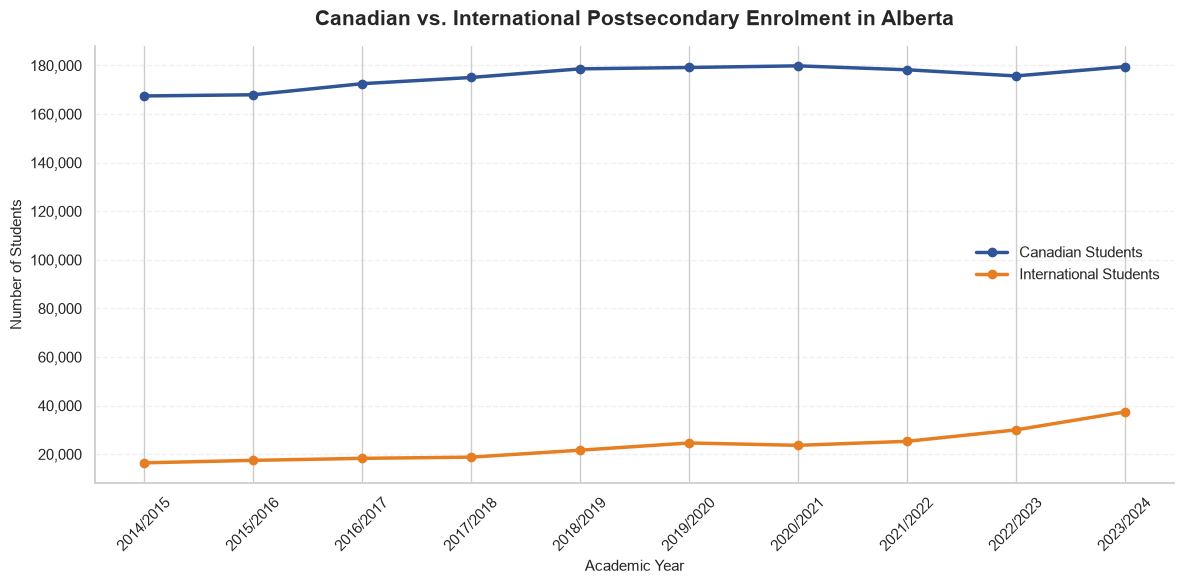

In [46]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Canadian enrolment
ax.plot(
    alberta_status["Academic_Year"],
    alberta_status["Canadian"],
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="Canadian Students",
    color="#2F5597"
)

# International enrolment
ax.plot(
    alberta_status["Academic_Year"],
    alberta_status["International"],
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="International Students",
    color="#E67E22"
)

# Title and labels
ax.set_title(
    "Canadian vs. International Postsecondary Enrolment in Alberta",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Academic Year", fontsize=11)
ax.set_ylabel("Number of Students", fontsize=11)

# Format y-axis
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter("{x:,.0f}")
)

# Rotate year labels
plt.xticks(rotation=45)

# Light grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(
    frameon=False,
    loc="best"
)

plt.tight_layout()
plt.show()

### Interpretation

Canadian enrolment remained comparatively stable over the period, increasing
from 167,463 students in 2014/15 to 179,535 in 2023/24.

International enrolment increased much more rapidly, rising from 16,458 to
37,416 students over the same period. Although international students remained
a smaller component of total enrolment, their substantially steeper growth
trajectory indicates that they became an increasingly important component of
Alberta's postsecondary enrolment base.

In [47]:
#Canadian enrolment = relatively stable; international enrolment = rapid growth.

## Visualization 2 — International Share of Alberta Postsecondary Enrolment

While international enrolment remained smaller than Canadian enrolment in
absolute terms, its share of Alberta's total reported postsecondary enrolment
increased substantially over the study period.

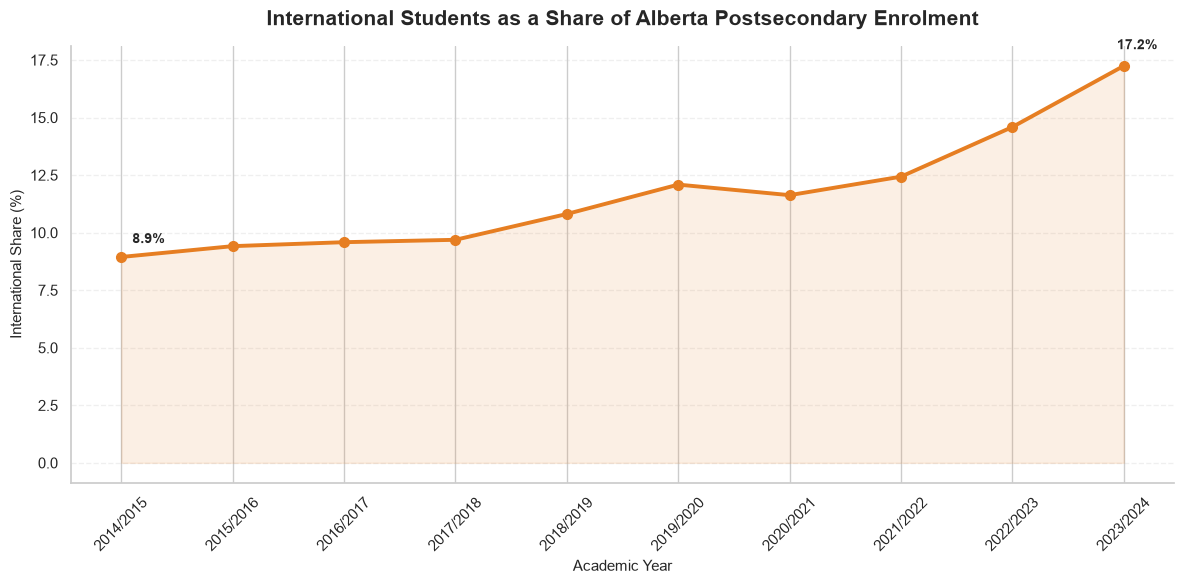

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    alberta_status["Academic_Year"],
    alberta_status["International_Share_Pct"],
    marker="o",
    linewidth=2.8,
    markersize=7,
    color="#E67E22"
)

# Light area shading
ax.fill_between(
    alberta_status["Academic_Year"],
    alberta_status["International_Share_Pct"],
    alpha=0.12,
    color="#E67E22"
)

# Highlight first and last values
start_share = alberta_status["International_Share_Pct"].iloc[0]
end_share = alberta_status["International_Share_Pct"].iloc[-1]

ax.annotate(
    f"{start_share:.1f}%",
    xy=(0, start_share),
    xytext=(8, 10),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

ax.annotate(
    f"{end_share:.1f}%",
    xy=(len(alberta_status) - 1, end_share),
    xytext=(-5, 12),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "International Students as a Share of Alberta Postsecondary Enrolment",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Academic Year", fontsize=11)
ax.set_ylabel("International Share (%)", fontsize=11)

plt.xticks(rotation=45)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

The international student share of Alberta's reported postsecondary enrolment
increased from 8.94% in 2014/15 to 17.25% in 2023/24, an increase of
8.30 percentage points.

Growth was relatively gradual during the first half of the period before
accelerating in the later years. After a temporary decline in 2020/21,
the international share increased in each subsequent year and reached its
highest level in 2023/24.

This indicates that international students became an increasingly significant
component of Alberta's postsecondary enrolment over the study period.

In [50]:
#Visualization 1: How many students are there?
#→ Canadian enrolment remained comparatively stable while international enrolment grew rapidly.

#Visualization 2: How did the composition change?
#→ International students went from roughly 1 in 11 students in 2014/15 to roughly 1 in 6 students in 2023/24.

## Visualization 3 — Institutions Driving International Enrolment Growth

Provincial growth was not distributed evenly across institutions. The following
analysis identifies the Alberta institutions that contributed the largest
absolute increases in international enrolment between 2014/15 and 2023/24.

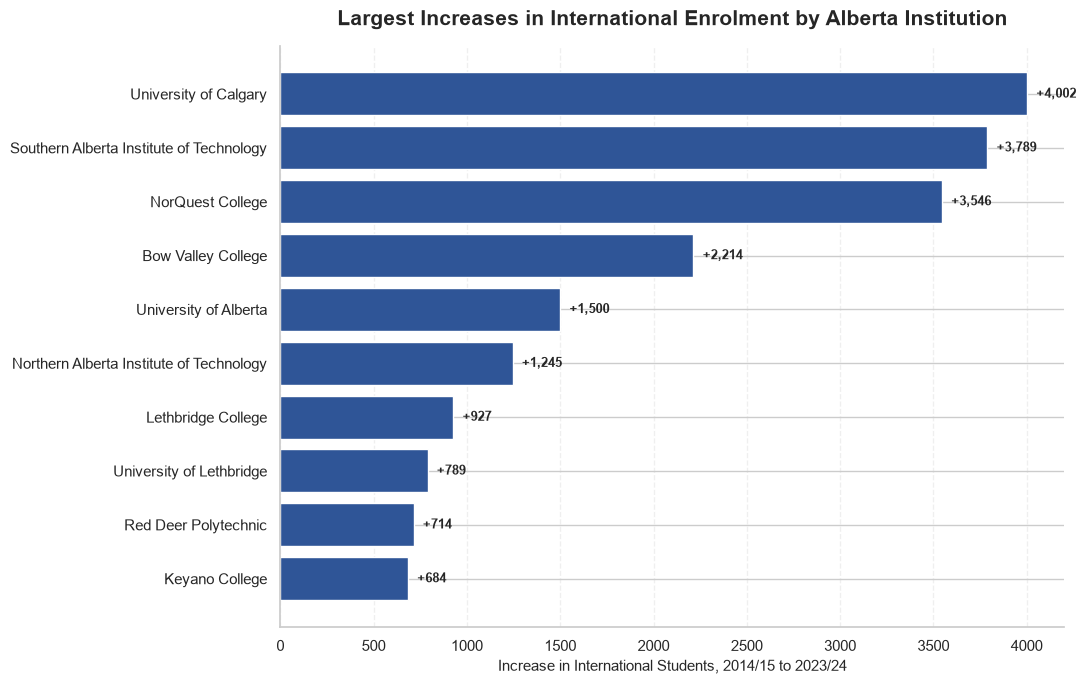

In [51]:
# Select the 10 institutions with the largest increase
top10_growth = (
    intl_growth
    .sort_values("Absolute_Change", ascending=False)
    .head(10)
    .sort_values("Absolute_Change")
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    top10_growth["Institution_Standardized"],
    top10_growth["Absolute_Change"],
    color="#2F5597"
)

# Add value labels
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 50,
        bar.get_y() + bar.get_height() / 2,
        f"+{value:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Largest Increases in International Enrolment by Alberta Institution",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Increase in International Students, 2014/15 to 2023/24",
    fontsize=11
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

International enrolment growth was concentrated among a relatively small
number of Alberta institutions.

The University of Calgary recorded the largest absolute increase, adding
4,002 international students between 2014/15 and 2023/24. It was followed
by the Southern Alberta Institute of Technology (SAIT), with an increase of
3,789, and NorQuest College, with an increase of 3,546.

Together, the top three institutions accounted for approximately 54% of
Alberta's net increase in international enrolment over the period. Expanding
the comparison to the top five institutions raises this contribution to
approximately 72%.

This concentration indicates that Alberta's growth in international
enrolment was driven disproportionately by a relatively small group of
institutions rather than being evenly distributed across the postsecondary
system.

In [54]:
#using absolute change for above chart, not percentage growth, for this visualization.

#That's deliberate. NorQuest's percentage increase is enormous because it started with only 99 international students. 
#A chart based purely on percentage growth could therefore make a relatively small institution look more important to Alberta's overall growth than it actually was.

## Visualization 4 — International Growth and Enrolment Exposure

Absolute growth alone does not show how dependent an institution has become on
international enrolment. This analysis compares each institution's increase in
international students with the share of its 2023/24 enrolment represented by
international students.

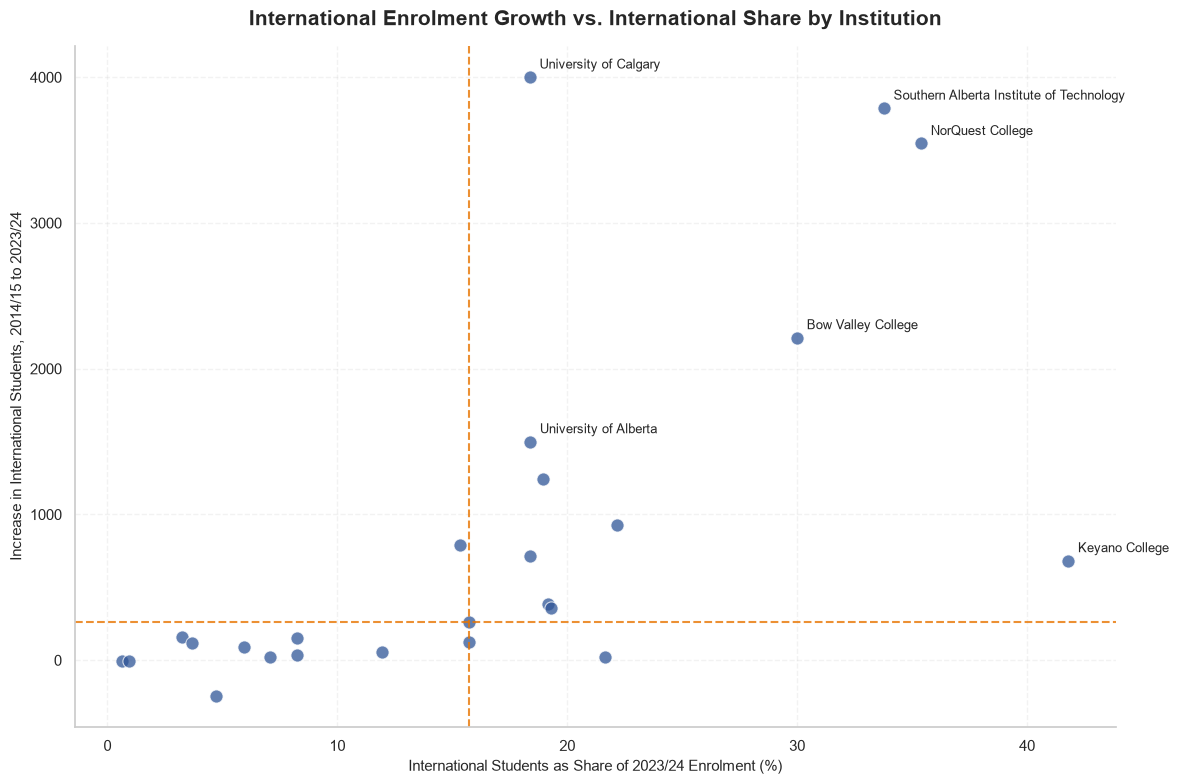

In [56]:
fig, ax = plt.subplots(figsize=(12, 8))

# Median values
median_growth = growth_exposure["Absolute_Change"].median()
median_share = growth_exposure["International_Share_Pct"].median()

# Scatter plot
ax.scatter(
    growth_exposure["International_Share_Pct"],
    growth_exposure["Absolute_Change"],
    s=90,
    color="#2F5597",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.8
)

# Median reference lines
ax.axvline(
    median_share,
    color="#E87500",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

ax.axhline(
    median_growth,
    color="#E87500",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# Label selected institutions
label_institutions = [
    "University of Calgary",
    "Southern Alberta Institute of Technology",
    "NorQuest College",
    "Bow Valley College",
    "University of Alberta",
    "Keyano College"
]

for _, row in growth_exposure.iterrows():

    if row["Institution_Standardized"] in label_institutions:

        ax.annotate(
            row["Institution_Standardized"],
            (
                row["International_Share_Pct"],
                row["Absolute_Change"]
            ),
            xytext=(7, 6),
            textcoords="offset points",
            fontsize=9
        )

ax.set_title(
    "International Enrolment Growth vs. International Share by Institution",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "International Students as Share of 2023/24 Enrolment (%)",
    fontsize=11
)

ax.set_ylabel(
    "Increase in International Students, 2014/15 to 2023/24",
    fontsize=11
)

ax.grid(
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretation

The relationship between international enrolment growth and international
student share reveals substantial differences across Alberta institutions.

The University of Calgary recorded the largest absolute increase in
international enrolment, while maintaining a comparatively moderate
international share of approximately 18%. In contrast, SAIT, NorQuest College,
and Bow Valley College combined large increases in international enrolment
with substantially higher international student shares.

Keyano College presents a different pattern. Although its absolute increase
was smaller than the largest growth institutions, international students
represented approximately 42% of its 2023/24 enrolment, the highest share
among the institutions analyzed.

The upper-right portion of the chart therefore identifies institutions where
international enrolment has become particularly important both in terms of
recent growth and current enrolment composition. This distinction is useful
because institutions experiencing similar absolute growth may have very
different levels of exposure to changes affecting international student
enrolment.

## Visualization 5 — International Growth Offset Against Canadian Enrolment Decline

Several Alberta institutions experienced declining Canadian enrolment while
simultaneously increasing international enrolment. Comparing these changes
shows whether international growth was sufficient to offset the decline in
Canadian students.

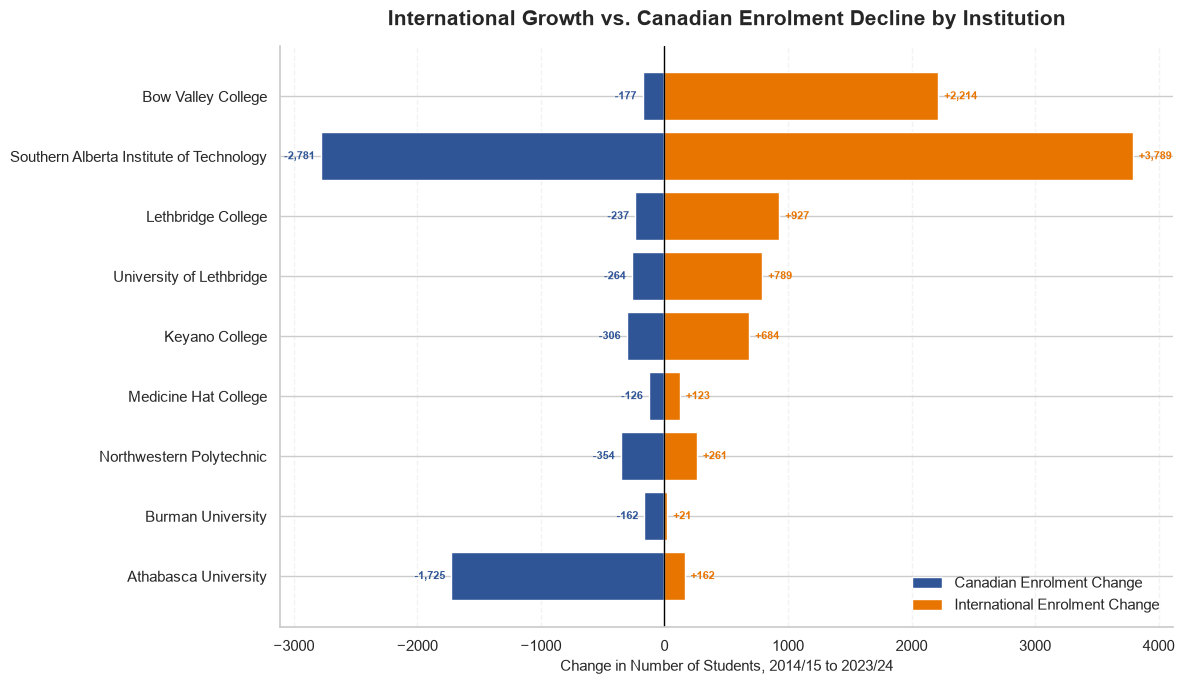

In [59]:
# Sort institutions by combined enrolment change
offset_plot = offset_analysis.sort_values(
    "Combined_Change",
    ascending=True
).copy()

fig, ax = plt.subplots(figsize=(12, 7))

y = range(len(offset_plot))

# Canadian enrolment change
ax.barh(
    y,
    offset_plot["Canadian_Change"],
    color="#2F5597",
    label="Canadian Enrolment Change"
)

# International enrolment change
ax.barh(
    y,
    offset_plot["International_Change"],
    color="#E87500",
    label="International Enrolment Change"
)

ax.set_yticks(y)
ax.set_yticklabels(offset_plot["Institution_Standardized"])

# Zero reference line
ax.axvline(
    0,
    color="black",
    linewidth=1
)

ax.set_title(
    "International Growth vs. Canadian Enrolment Decline by Institution",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Change in Number of Students, 2014/15 to 2023/24",
    fontsize=11
)

ax.set_ylabel("")

ax.legend(
    frameon=False,
    loc="lower right"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add value labels
for i, value in enumerate(offset_plot["Canadian_Change"]):
    ax.text(
        value - 50,
        i,
        f"{value:,.0f}",
        va="center",
        ha="right",
        fontsize=8,
        color="#2F5597",
        fontweight="bold"
    )

for i, value in enumerate(offset_plot["International_Change"]):
    ax.text(
        value + 50,
        i,
        f"+{value:,.0f}",
        va="center",
        ha="left",
        fontsize=8,
        color="#E87500",
        fontweight="bold"
    )


plt.tight_layout()
plt.show()

### Interpretation

Nine Alberta institutions experienced a decline in Canadian enrolment while
simultaneously recording growth in international enrolment between 2014/15
and 2023/24.

At five of these institutions, international enrolment growth was large enough
to fully offset the decline in Canadian students. Bow Valley College provides
the clearest example, where a decline of 177 Canadian students was accompanied
by an increase of 2,214 international students. SAIT also experienced a
substantial shift, with international enrolment increasing by 3,789 while
Canadian enrolment declined by 2,781.

At the remaining four institutions, international growth only partially offset
Canadian enrolment losses. Athabasca University shows the strongest example:
Canadian enrolment declined by 1,725 students while international enrolment
increased by only 162.

These results show that international enrolment growth played very different
roles across institutions. For some, it more than compensated for declining
Canadian enrolment, while for others it provided only a limited offset.